# 15.777 Homework 1 (Spring 2024): Convolutional Neural Networks

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# initialize the seeds of different random number generators so that the
# results will be the same every time the notebook is run
keras.utils.set_random_seed(42)

# Introduction

Your goal in this exercise is to detect emotion from a facial image. To that end, we will use the 2013 Facial Expression Recognition (FER) dataset.

The dataset consists of ~36,000 images, each annotated with one of seven labels:
* angry
* disgust
* fear
* happy
* sad
* surprise
* neutral

The goal of this homework assignment is to walk you through how to:

1. Build a Convolutional Neural Network (CNN) *from scratch* to detect emotion in facial images (Problem 1 and 2)
2. Use data augmentation to increase the size of your training data (Problem 3)
3. Use transfer learning to customize a pretrained model to solve the same problem (Problem 4)

But first, let's get the data.

In [ ]:
!wget -q -O fer2013.csv -P ./ https://dl.dropbox.com/scl/fi/e2ik6aryemboameq1rwwn/fer2013.csv?rlkey=ux7tyge6flk9nnuul9desizgf&dl=0

The data has 35887 rows and 3 columns:
* Emotion - encoded as the numbers 0 (anger) through 6 (neutral)
* Pixels - A space-separated list of numbers representing the pixels of this image.
* Usage - No need to worry about this column

In [ ]:
data = pd.read_csv('fer2013.csv')
data

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training
...,...,...,...
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest


The pixel values for each image is provided as a space-separated list of numbers. How many pixels in an image?

In [ ]:
len(data.loc[0, 'pixels'].split(' '))

2304

### Pre-Processing the Pixels (Independent Variable)

Each image is encoded as a list of 2304 pixels. We will reshape this into an 48x48 image next.

Recall that a color image is represented as a tensor of dimension N by M by 3, where the 3 represents the 3 color channels (red, green and blue). Our images from the FER 2013 dataset are grayscale images, with only a single channel representing the amount of black in the image. This is inconvenient to work with because many pre-trained models used in transfer learning, such as the one we will use in Problem 4, require the input image to have 3 channels.

To get around this, we will take each image, a 48 x 48 tensor and transform it into a 48 x 48 x 3 tensor by simply duplicating it three times. We can think of a greyscale image is one where the red, green and blue color channels are exactly the same.

The following code transforms our dataset into a tensor of shape (35887, 48, 48, 3): a list of 35887 images, each of which are a (48, 48, 3)-shape tensor.

In [ ]:
pixels = data['pixels'].tolist()
width, height = 48, 48
faces = []
for pixel_sequence in pixels:
    face = [int(pixel) for pixel in pixel_sequence.split(' ')] # read each face as a 1-d array
    face = np.asarray(face).reshape(width, height) # reshape the length 2304 1-d array into an 48x48 array
    face = np.stack((face,)*3, axis=-1)
    faces.append(face.astype('float32'))

faces = np.asarray(faces)
faces.shape

(35887, 48, 48, 3)

For the first image, i.e. `faces[0]`, we can examine its first channel (corresponding to "red").

In [ ]:
faces[0, :, :, 0]

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

This is the exact same as the second channel (corresponding to "blue"). And similarly for green.

In [ ]:
faces[0, :, :, 1]

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

### Pre-Processing for Emotions (Dependent Variable)

Next, let's take a look at how emotion (the dependent variable) is encoded. We have that 0 = 'angry', 1 = 'disgust', ... 6 = 'neutral'.

In [ ]:
data.emotion.unique()

array([0, 2, 4, 6, 3, 5, 1])

We will convert emotion to a one-hot encoding using the `pd.get_dummies` function.

In [ ]:
emotions = pd.get_dummies(data['emotion']).to_numpy() # each emotion is 'one-hot' encoded as a 7-dim vector
emotions_names = ('angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral')
emotions.shape

(35887, 7)

### Example Images
Lets take a look at some of these fun images!

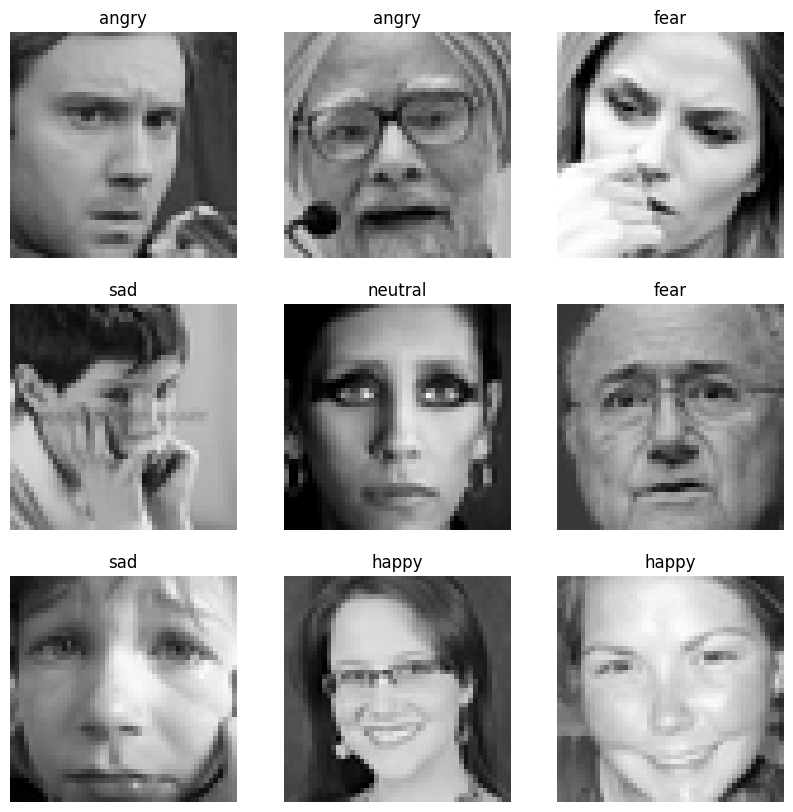

In [ ]:
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1)
    ax.set_title(f"{emotions_names[np.argmax(emotions[i])]}")
    ax.imshow(faces[i].astype('uint8'))
    ax.axis('off')

### Train/Test Split
As in the original dataset, we will reserve the first 28,709 images for training and the rest for testing.

In [ ]:
train_faces, train_emotions =  faces[:28709], emotions[:28709]
test_faces, test_emotions =  faces[28709:], emotions[28709:]

train_faces.shape, train_emotions.shape, test_faces.shape, test_emotions.shape

((28709, 48, 48, 3), (28709, 7), (7178, 48, 48, 3), (7178, 7))

# Problem 1: Base Model [30 Points]
In this problem, we will build a simple CNN with three convolutional blocks, one dense layer and one output layer.



## Part (a): Building the Model [10 points]
We would like to build a CNN with the following model summary. Fill in the code in the cell below so that the output of `model.summary()` matches that of the image above. Be sure to use relu activation for each of the Conv2D layers and the appropriate activation function for the output layer.


![](https://dl.dropbox.com/scl/fi/lrmaupoa243xrrsfj3qiy/cnn_model.PNG?rlkey=n5axqin6vx652qrgduyosg0pc&dl=0)

In [ ]:
input = keras.Input(shape=(48, 48, 3), name="input")

###### YOUR CODE HERE #####
x = keras.layers.Rescaling(1./255)(input) #normalizing
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_1")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_2")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_3")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)

output = keras.layers.Dense(7, activation="softmax", name="output")(x)
###### YOUR CODE HERE #####

model = keras.Model(input, output, name='CNN_model')
model.summary()

Model: "CNN_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 48, 48, 3)]       0         
                                                                 
 rescaling (Rescaling)       (None, 48, 48, 3)         0         
                                                                 
 Conv_1 (Conv2D)             (None, 47, 47, 16)        208       
                                                                 
 max_pooling2d (MaxPooling2  (None, 23, 23, 16)        0         
 D)                                                              
                                                                 
 Conv_2 (Conv2D)             (None, 22, 22, 16)        1040      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 11, 11, 16)        0         
 g2D)                                                    

## Part (b): Number of Parameters [10 points]
The model above has $106,743$ trainable parameters and is computed by $208 + 1040 + 1040 + 102656 + 1799$. Explain how each of these 5 numbers is calculated and show your computations (e.g. 208 = 16 * 3 * 4 + 16).


<font color='red'>**Your Answer.**</font>

_Please replace this text with your answer_

* The first convolution layer has 16 filters. Each filter has 3 channels and is $2 \times 2$ in size. This leads to $16 \cdot 3 \cdot 4 = 192$ parameters. There are also $16$ biases, one for each filter, for a total of $208$.
* The second and third convolution layers have $16 \times (2 \times 2) \times 16 + 16 = 1040$ parameters. There are $16$ channels passed from the previous layer (`max_pooling2d`, `max_pooling2d_1`) and 16 filters at this layer.
* For `dense_1`, the previous layer has 400 nodes and `dense_2` has 256 nodes. Fully connected, this gives $400 \cdot 256 + 256 = 102,656$ parameters.
* The output layer has 1799 parameters from $256 \cdot 7 + 7 = 1799$.

## Part (c): Training and Evaluation [10 points]

Let us compile our model and fit it on the training data. Since we one-hot-encoded the dependent variable, we use `categorical_crossentropy`, not `sparse_categorical_crossentropy`.

Fill in the parameters of `model.compile` and `model.fit` below.

* Compile the model using the `categorical_crossentropy` loss, `adam` optimizer and report the `accuracy` metric.
* Fit the model on `train_faces`, `train_emotions` using a batch size of 64, for 30 epochs and a validation split of 20%.

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

model_history = model.fit(
    train_faces,
    train_emotions,
    batch_size=64,
    epochs=30,
    validation_split=0.2,
)

Epoch 1/30
359/359 [==============================] - 7s 7ms/step - loss: 1.7356 - accuracy: 0.2992 - val_loss: 1.6440 - val_accuracy: 0.3680
Epoch 2/30
359/359 [==============================] - 2s 5ms/step - loss: 1.5717 - accuracy: 0.3912 - val_loss: 1.5212 - val_accuracy: 0.4220
Epoch 3/30
359/359 [==============================] - 2s 5ms/step - loss: 1.4913 - accuracy: 0.4229 - val_loss: 1.4669 - val_accuracy: 0.4277
Epoch 4/30
359/359 [==============================] - 2s 5ms/step - loss: 1.4195 - accuracy: 0.4523 - val_loss: 1.4015 - val_accuracy: 0.4633
Epoch 5/30
359/359 [==============================] - 2s 5ms/step - loss: 1.3651 - accuracy: 0.4759 - val_loss: 1.3747 - val_accuracy: 0.4747
Epoch 6/30
359/359 [==============================] - 2s 4ms/step - loss: 1.3213 - accuracy: 0.4942 - val_loss: 1.3677 - val_accuracy: 0.4747
Epoch 7/30
359/359 [==============================] - 2s 4ms/step - loss: 1.2742 - accuracy: 0.5139 - val_loss: 1.3395 - val_accuracy: 0.4986
Epoch 

**Epochs and Batches.**

In your own words, please explain the relationship between an epoch and a batch in stochastic gradient descent.

<font color='red'>**Your Answer.**</font>

_Stochastic gradient descent changes the weights of our model based on the gradient with respect to a batch of points. The training data is divided into batches and an epoch represents a single pass through the training data._




When we ran `model.fit`, we saw that there are 359 batches per epoch. Please explain how this 359 is calculated. _Hint_: There are 28,709 training data points and 20% is set aside for validation.

<font color='red'>**Your Answer.**</font>

_The training set has 28,709 data points, of which 20% is set aside for validation. Out of the 22,967 remaining data points, we divide them into batches of size 64, giving 22967/64 = 358.8. Therefore, there are 358 batches of size 64 and one batch of size 55 for a total of 359 batches._

**Plotting the Training/Validation Accuracy Curve**

Use the `plot_accuracy` function below to plot the training and validation accuracy across the training epochs.

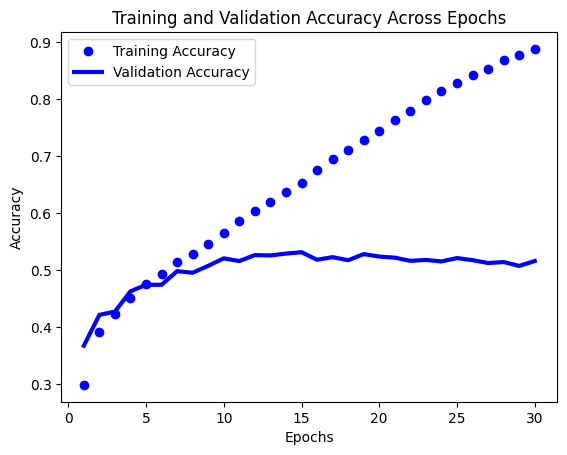

In [ ]:
def plot_accuracy(model_history):
    history_dict = model_history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training Accuracy", linewidth=3)
    plt.plot(epochs, val_acc, "b", label="Validation Accuracy", linewidth=3)
    plt.title("Training and Validation Accuracy Across Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_accuracy(model_history)

**Model Accuracy**

Calculate the accuracy on the test set. Write your code below to show the accuracy.

In [ ]:
### YOUR CODE HERE ###
model.evaluate(test_faces, test_emotions)[1]

225/225 [==============================] - 1s 3ms/step - loss: 2.4125 - accuracy: 0.5050


0.5050153136253357

# Problem 2: Wider and Deeper Models [30 Points]
In this problem, we will modify the model from Problem 1 in two ways:
* Increase the width of the model by adding more filters and more neurons in the dense layer.
* Increase the depth of the model by adding another dense layer.

### Part (a): Wider Model [5 points]
Take the `model` from Problem 1 and modify it into `wider_model` by using 32 filters for the convolution layers instead of 16.


Write your new code below and verify that `wider_model.summary()` looks correct. Your model should have 215,527 parameters.



In [ ]:
input = keras.Input(shape=train_faces.shape[1:])

### YOUR CODE BELOW ###
x = keras.layers.Rescaling(1./255)(input) #normalizing
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_1")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_2")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_3")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)
output = keras.layers.Dense(7, activation="softmax", name="output")(x)
### YOUR CODE ABOVE ###

wider_model = keras.Model(input, output, name='wider_cnn')
wider_model.summary()

Model: "wider_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 48, 48, 3)]       0         
                                                                 
 rescaling_1 (Rescaling)     (None, 48, 48, 3)         0         
                                                                 
 Conv_1 (Conv2D)             (None, 47, 47, 32)        416       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 23, 23, 32)        0         
 g2D)                                                            
                                                                 
 Conv_2 (Conv2D)             (None, 22, 22, 32)        4128      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 11, 11, 32)        0         
 g2D)                                                    

## Part (b): Number of Parameters [5 points]
The model above has $215,527$ trainable parameters and is computed by $416 + 4128 + 4128 + 205,056 + 1799$. Explain how each of these 5 numbers is calculated and show your computations.

<font color='red'>**Your Answer.**</font>

_Please replace this text with your answer_

* The first convolution layer has 32 filters. Each filter has 3 channels and is $2 \times 2$ in size. This leads to $32 \cdot 3 \cdot 4 = 384$ parameters. There are also $32$ biases, one for each filter, for a total of $416$.
* The second and third convolution layers have $32 \times (2 \times 2) \times 32 + 32 = 4128$ parameters. There are $16$ channels passed from the previous layer (`max_pooling2d`, `max_pooling2d_1`) and 16 filters at this layer.
* For `dense_1`, the previous layer has 800 nodes and `dense_2` has 256 nodes. Fully connected, this gives $800 \cdot 256 + 256 = 205,056$ parameters.
* The output layer has 1799 parameters from $256 \cdot 7 + 7 = 1799$.


## Part (c): Training and Evaluation [5 points]
Let's train our model and evaluate its performance.

In [ ]:
### YOUR CODE HERE ###
wider_model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

wider_model_history = wider_model.fit(train_faces, train_emotions,
          batch_size=64,
          epochs=30,
          validation_split=0.2)

Epoch 1/30
359/359 [==============================] - 4s 6ms/step - loss: 1.7065 - accuracy: 0.3131 - val_loss: 1.5761 - val_accuracy: 0.4011
Epoch 2/30
359/359 [==============================] - 2s 5ms/step - loss: 1.4978 - accuracy: 0.4255 - val_loss: 1.4610 - val_accuracy: 0.4483
Epoch 3/30
359/359 [==============================] - 2s 5ms/step - loss: 1.3989 - accuracy: 0.4636 - val_loss: 1.3518 - val_accuracy: 0.4842
Epoch 4/30
359/359 [==============================] - 2s 5ms/step - loss: 1.3237 - accuracy: 0.4951 - val_loss: 1.3148 - val_accuracy: 0.4991
Epoch 5/30
359/359 [==============================] - 2s 5ms/step - loss: 1.2639 - accuracy: 0.5182 - val_loss: 1.3063 - val_accuracy: 0.5113
Epoch 6/30
359/359 [==============================] - 2s 5ms/step - loss: 1.2089 - accuracy: 0.5432 - val_loss: 1.2700 - val_accuracy: 0.5185
Epoch 7/30
359/359 [==============================] - 2s 5ms/step - loss: 1.1528 - accuracy: 0.5666 - val_loss: 1.2482 - val_accuracy: 0.5305
Epoch 

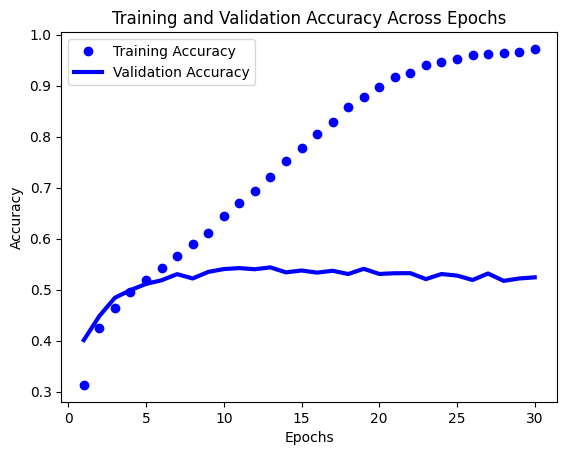

In [ ]:
### YOUR CODE HERE ###
plot_accuracy(wider_model_history)

In [ ]:
### YOUR CODE HERE ###
wider_model.evaluate(test_faces, test_emotions)[1]

225/225 [==============================] - 1s 3ms/step - loss: 3.7230 - accuracy: 0.5163


0.5162997841835022

Compare the accuracy curve of `wider_model` to that of `model` from Problem 1. Which shows more evidence of overfitting after 30 epochs? Does that make sense?

<font color='red'> **Your Answer.** </font>

_Wider model shows more evidence of overfitting as the training accuracy reaches 100% much sooner than that of the original model. This makes sense because wider model has more parameters and thus the optimizer has more flexibility in reducing the training loss._



## Part (d): Deeper Model [5 Points]
Now, build a new model called `deep_model` by taking `model` from Problem 1 and add an additional dense layer of 256 nodes immediately after the original dense layer of 256 nodes. The new model should have a total of 2 dense layers of 256 nodes each and have a total of 172,535 parameters.

Train the model, plot its accuracy vs epochs using the `plot_accuracy` function, and report the model's accuracy on the test set.

In [ ]:
input = keras.Input(shape=train_faces.shape[1:])

### YOUR CODE BELOW ###

x = keras.layers.Rescaling(1./255)(input) #normalizing
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_1")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_2")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(16, kernel_size=(2, 2), activation="relu", name="Conv_3")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dense(256, activation="relu")(x)

output = keras.layers.Dense(7, activation="softmax", name="output")(x)

### YOUR CODE ABOVE ###

deeper_model = keras.Model(input, output, name='deeper_cnn')
deeper_model.summary()

Model: "deeper_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 48, 48, 3)]       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 48, 48, 3)         0         
                                                                 
 Conv_1 (Conv2D)             (None, 47, 47, 16)        208       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 23, 23, 16)        0         
 g2D)                                                            
                                                                 
 Conv_2 (Conv2D)             (None, 22, 22, 16)        1040      
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 11, 11, 16)        0         
 g2D)                                                   

In [ ]:
### YOUR CODE HERE ###
deeper_model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

deeper_model_history = deeper_model.fit(train_faces, train_emotions,
          batch_size=64,
          epochs=30,
          validation_split=0.2)

Epoch 1/30
359/359 [==============================] - 4s 6ms/step - loss: 1.7386 - accuracy: 0.2910 - val_loss: 1.6212 - val_accuracy: 0.3683
Epoch 2/30
359/359 [==============================] - 2s 5ms/step - loss: 1.5521 - accuracy: 0.3967 - val_loss: 1.4957 - val_accuracy: 0.4272
Epoch 3/30
359/359 [==============================] - 2s 5ms/step - loss: 1.4628 - accuracy: 0.4308 - val_loss: 1.4156 - val_accuracy: 0.4565
Epoch 4/30
359/359 [==============================] - 2s 5ms/step - loss: 1.3846 - accuracy: 0.4666 - val_loss: 1.3755 - val_accuracy: 0.4690
Epoch 5/30
359/359 [==============================] - 2s 5ms/step - loss: 1.3256 - accuracy: 0.4901 - val_loss: 1.3560 - val_accuracy: 0.4800
Epoch 6/30
359/359 [==============================] - 2s 5ms/step - loss: 1.2671 - accuracy: 0.5174 - val_loss: 1.3404 - val_accuracy: 0.4857
Epoch 7/30
359/359 [==============================] - 2s 5ms/step - loss: 1.2070 - accuracy: 0.5415 - val_loss: 1.3206 - val_accuracy: 0.5085
Epoch 

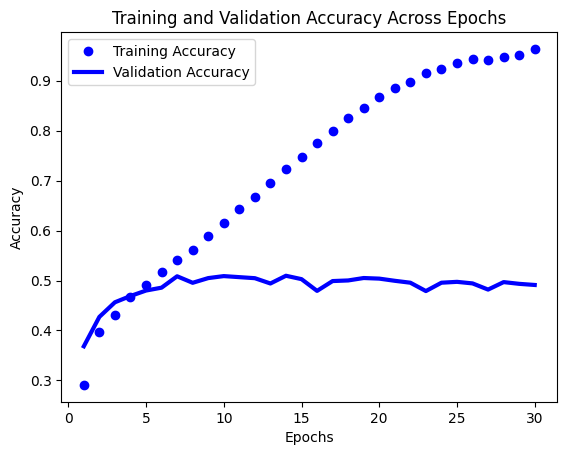

In [ ]:
## YOUR CODE HERE: Plot accuracy curve
plot_accuracy(deeper_model_history)

In [ ]:
### YOUR CODE HERE ###
deeper_model.evaluate(test_faces, test_emotions)

225/225 [==============================] - 1s 2ms/step - loss: 3.7946 - accuracy: 0.4950


[3.794559955596924, 0.4949846863746643]

## Part (e): Comparison [10 points]
Comment on the difference between the test accuracy of `model`, `wider_model` and `deeper_model`. Did widening the model or deepening the model result in a better performance? Why? Do you think
this result generally holds true for all problems?

<font color='red'>**Your Answer**</font>


Test Accuracy Comparison:
* `model`: 50.1%
* `wider_model`: 51.6%
* `deeper_model`: 47.9%

_`wider_model` performed better (51.8% vs. 48.8%) than `deeper_model`. Adding more filters allows the model to learn more representations (i.e. more lines and circles), showing that the original 16 filters per layer were insufficient. Adding another dense layer to the end of the model allows the model to better predict the dependent variable given the represntation extracted from the filters. However, it seemed the latter was not the bottleneck in this problem setting. This may not hold for all problem settings. It is difficult whether a wider or deeper model will do better without just trying both approaches._

# Problem 3: Data Augmentation [15 Points]

The basic idea of augmentation is to alter the image so slightly that the value of the dependent variable (i.e. the category that it belongs to) doesn't change.

Keras allows us to easily perform data augmentation using layers such as:

* `keras.layers.RandomFlip`
* `keras.layers.RandomZoom`
* `keras.layers.RandomRotation`

Lets quickly visualize what the augmentation does ... Here, we flip the images horizontally, then apply a random zoom of up to 20%. Note that you do not need to understand how the code below works. Most of it is there to allow us to visualize the augmentation.

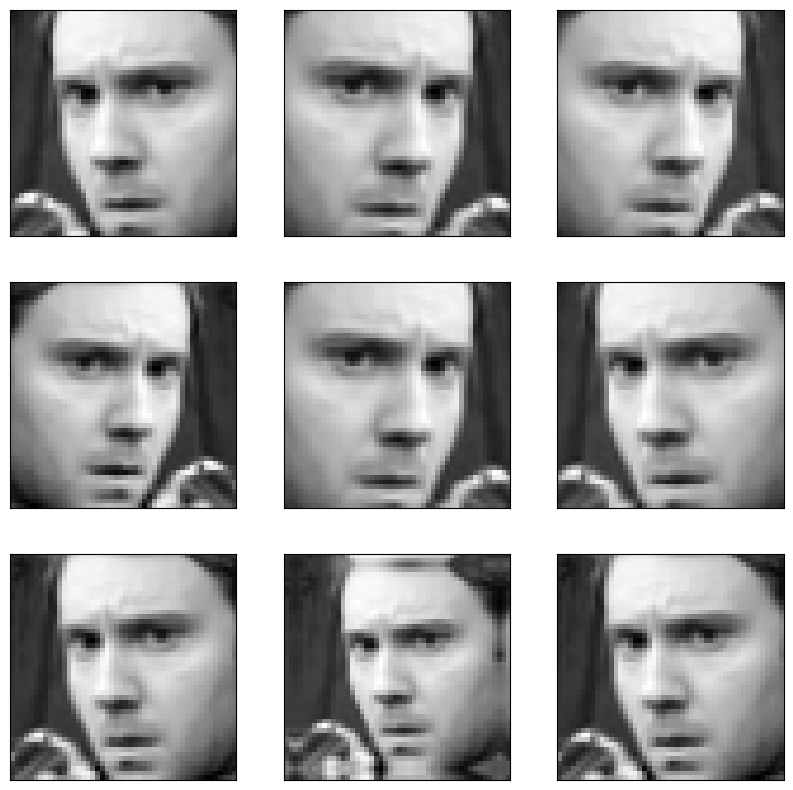

In [ ]:
def augment_images(image):
    x = keras.layers.RandomFlip("horizontal")(image)
    x = keras.layers.RandomZoom(0.2)(x)
    return x

augmented_images = [augment_images(np.expand_dims(train_faces[0],axis=0)) for i in range(9)]
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1, xticks=[], yticks=[])
    ax.imshow(tf.keras.preprocessing.image.array_to_img(augmented_images[i][0]), cmap='gray', vmin=0, vmax=255)

We take our model `wider_model` from Problem 2(c) and add a random flip and random zoom as **layers** before the rescaling layer.

In [ ]:
input = keras.Input(shape=(48, 48, 3))

### DATA AUGMENTATION ###
x = keras.layers.RandomFlip("horizontal")(input)
x = keras.layers.RandomZoom(0.2)(x)

x = keras.layers.Rescaling(1./255)(x)
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_1")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_2")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Conv2D(32, kernel_size=(2, 2), activation="relu", name="Conv_3")(x) # convolutional layer!
x = keras.layers.MaxPool2D()(x) # pooling layer
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)
output = keras.layers.Dense(7, activation="softmax")(x)

model_augmented = keras.Model(input, output, name='augmented_CNN_model')
model_augmented.summary()

Model: "augmented_CNN_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 48, 48, 3)]       0         
                                                                 
 random_flip_9 (RandomFlip)  (None, 48, 48, 3)         0         
                                                                 
 random_zoom_9 (RandomZoom)  (None, 48, 48, 3)         0         
                                                                 
 rescaling (Rescaling)       (None, 48, 48, 3)         0         
                                                                 
 Conv_1 (Conv2D)             (None, 47, 47, 32)        416       
                                                                 
 max_pooling2d (MaxPooling2  (None, 23, 23, 32)        0         
 D)                                                              
                                               

Train the model (using the same parameters as all previous questions), show the accuracy vs. epoch curve, and report the accuracy on the test set.

In [ ]:
model_augmented.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

model_augmented_history = model_augmented.fit(train_faces, train_emotions,
          batch_size=64,
          epochs=30,
          validation_split=0.2)

Epoch 1/30
359/359 [==============================] - 4s 6ms/step - loss: 1.7461 - accuracy: 0.2879 - val_loss: 1.6316 - val_accuracy: 0.3659
Epoch 2/30
359/359 [==============================] - 2s 5ms/step - loss: 1.5885 - accuracy: 0.3858 - val_loss: 1.4854 - val_accuracy: 0.4331
Epoch 3/30
359/359 [==============================] - 2s 5ms/step - loss: 1.5017 - accuracy: 0.4216 - val_loss: 1.4363 - val_accuracy: 0.4432
Epoch 4/30
359/359 [==============================] - 2s 5ms/step - loss: 1.4310 - accuracy: 0.4485 - val_loss: 1.3880 - val_accuracy: 0.4643
Epoch 5/30
359/359 [==============================] - 2s 5ms/step - loss: 1.3806 - accuracy: 0.4675 - val_loss: 1.3227 - val_accuracy: 0.4979
Epoch 6/30
359/359 [==============================] - 2s 5ms/step - loss: 1.3443 - accuracy: 0.4857 - val_loss: 1.3208 - val_accuracy: 0.4960
Epoch 7/30
359/359 [==============================] - 2s 5ms/step - loss: 1.3079 - accuracy: 0.5009 - val_loss: 1.2808 - val_accuracy: 0.5188
Epoch 

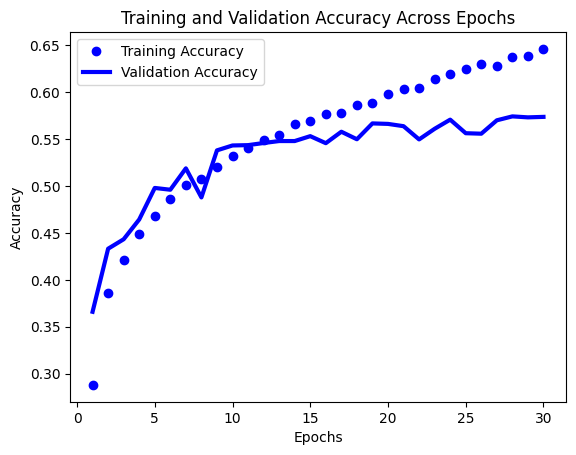

In [ ]:
plot_accuracy(model_augmented_history)

In [ ]:
model_augmented.evaluate(test_faces, test_emotions)[1]

225/225 [==============================] - 1s 2ms/step - loss: 1.2089 - accuracy: 0.5683


0.5682641267776489

Compare this with `wider_model` and comment on the impact of data augmentation.

* Did data augmentation reduce overfitting?
* Did data augmentation improve test set accuracy

<font color='red'> **Your Answer.** </font>

_It is clear that data augmentation is very helpful, raising the test accuracy from 51.8% to 56.8%, a major improvement! Overfitting also seems to be reduced as the validation accuracy curve is increasing for longer and the training accuracy curve no longer hits 100% so quickly._

# Problem 4: Transfer Learning and Fine-Tuning [25 points]

Next, we apply transfer learning to our problem using VGG19, a pre-trained model similar to ResNet50 from class. We will take VGG19 and make it "headless", then run it through our own "little" NN.

We will take three different approaches to this:

1. Part (a): **Base Transfer Learning**. Fix the weights from headless VGG19 and learn the weights on the little NN.
2. Part (b): **Some fine-tuning** Fix the weights on the top 6 out of 19 layers of VGG19, but allow the weights from the remaining 13 layers to be optimized by SGD/Adam, in addition to those of the little NN.
3. Part (c): **Fine-Tuning** Allow all weights in VGG19 to be tuned, in addition to the little NN.

For each of the models, we will plot their train/validation accuracy curve, compute their test accuracy, and compute a confusion matrix.

## Part (a): No Fine Tuning [5 Points]

Let us fetch the VGG19 model, making sure to set `include_top=False` so that we do not take its output layer. We also set `trainable=False` to indicate that the parameters in these 19 layers are not trainable.



In [ ]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=(48, 48, 3),
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

# Freeze the base_model so that it is not trainable at all
base_model.trainable = False

80134624/80134624 [==============================] - 4s 0us/step


We build a neural network that performs data augmentation and rescaling, then uses the VGG19, and finally has one dense layer before the output layer.

In [ ]:
inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add layers from base_model one at a time
for layer in base_model.layers:
    x = layer(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

transfer_model = keras.Model(inputs, outputs, name='transfer_model')
transfer_model.summary()

Model: "transfer_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 48, 48, 3)]       0         
                                                                 
 random_flip_3 (RandomFlip)  (None, 48, 48, 3)         0         
                                                                 
 random_zoom_3 (RandomZoom)  (None, 48, 48, 3)         0         
                                                                 
 rescaling_6 (Rescaling)     (None, 48, 48, 3)         0         
                                                                 
 input_4 (InputLayer)        multiple                  0         
                                                                 
 block1_conv1 (Conv2D)       (None, 48, 48, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 48, 48, 64)     

Train the model. Here, we use a learning rate of 0.00002 to get better convergence.

In [ ]:
transfer_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

transfer_model_history = transfer_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 [==============================] - 7s 8ms/step - loss: 1.8027 - accuracy: 0.2603 - val_loss: 1.7315 - val_accuracy: 0.2882
Epoch 2/30
718/718 [==============================] - 5s 6ms/step - loss: 1.7246 - accuracy: 0.3057 - val_loss: 1.6847 - val_accuracy: 0.3224
Epoch 3/30
718/718 [==============================] - 5s 6ms/step - loss: 1.6946 - accuracy: 0.3248 - val_loss: 1.6630 - val_accuracy: 0.3340
Epoch 4/30
718/718 [==============================] - 5s 6ms/step - loss: 1.6802 - accuracy: 0.3280 - val_loss: 1.6483 - val_accuracy: 0.3412
Epoch 5/30
718/718 [==============================] - 5s 6ms/step - loss: 1.6676 - accuracy: 0.3344 - val_loss: 1.6393 - val_accuracy: 0.3474
Epoch 6/30
718/718 [==============================] - 5s 6ms/step - loss: 1.6612 - accuracy: 0.3421 - val_loss: 1.6285 - val_accuracy: 0.3549
Epoch 7/30
718/718 [==============================] - 5s 6ms/step - loss: 1.6515 - accuracy: 0.3447 - val_loss: 1.6253 - val_accuracy: 0.3534
Epoch 

We can plot the training and validation accuracy curve.

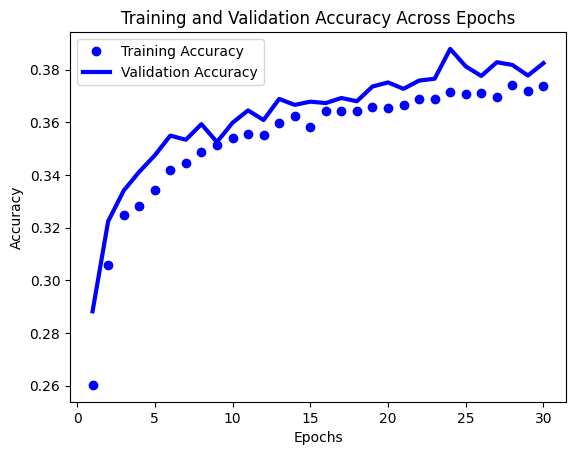

In [ ]:
plot_accuracy(transfer_model_history)

Let's also calculate the confusion matrix and the accuracy on the test set.

The function `show_confusion_matrix` has been written for you below. You can apply it to any Keras Model and it will calculate:
* Test accuracy
* A confusion matrix. Recall that each row of the confusion matrix are the actual labels and each column are the predictions. For example, if element in row `happy` and column `sad` is 250, then there are 250 data points in the test set where the true label is `happy` but we predicted `sad`.
* A heatmap of the confusion matrix, where each row is normalized to add up to 1.0. For example, if element in row `happy` and column `sad` is 0.25, then that means 25% of data points with a true label of `happy` were predicted as `sad`.

225/225 [==============================] - 1s 4ms/step
*************************
* Test Accuracy: 0.3763 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,125,0,41,463,117,74,138
disgust,9,0,11,57,13,8,13
fear,51,0,118,414,149,165,127
happy,61,0,43,1363,111,56,140
sad,87,0,73,568,314,44,161
surprise,26,0,52,205,24,435,89
neutral,74,0,44,594,107,68,346


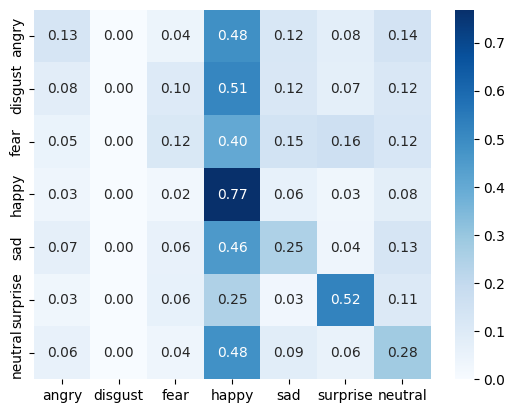

In [ ]:
from IPython.display import display

def show_confusion_matrix(model):
    """
    Calculates the test accuracy, confusion matrix and heat map for a model.
    """
    global test_faces, test_emotions, emotions_names

    y_pred = model.predict(test_faces).argmax(axis=1)
    y_actual = test_emotions.argmax(axis=1)

    print('*************************\n* Test Accuracy: %.4f *\n*************************' % metrics.accuracy_score(y_actual, y_pred))

    cm = pd.DataFrame(metrics.confusion_matrix(y_actual, y_pred), index=emotions_names, columns=emotions_names)
    display(cm)

    cm = cm.div(cm.sum(axis=1), axis=0)

    sns.heatmap(cm, cmap="Blues", annot=True, fmt=".2f")

show_confusion_matrix(transfer_model)

Please comment briefly on the model's performance.

<font color='red'> **Your Answer** </font>

_This model performs fairly poorly with a test accuracy of only 37.2%. There is little sign of overfitting. The confusion matrix shows that this model disproportionaly classifies every image as `happy`._

## Part (b): Some Fine Tuning [5 Points]
In this part, we will allow our optimization model to tune **some** of the layers from VGG19. In particular, we will only freeze the first 15 layers and allow the remaining layers to be trained.


In [ ]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add layers from base_model
for layer in base_model.layers:
    x = layer(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

partial_model = keras.Model(inputs, outputs, name='partial_fine_tune_model')

# Make the first 15 layers not trainable. All other layers are trainable
for layer in partial_model.layers[:15]:
    layer.trainable = False

partial_model.summary()

Model: "partial_fine_tune_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 48, 48, 3)]       0         
                                                                 
 random_flip_4 (RandomFlip)  (None, 48, 48, 3)         0         
                                                                 
 random_zoom_4 (RandomZoom)  (None, 48, 48, 3)         0         
                                                                 
 rescaling_7 (Rescaling)     (None, 48, 48, 3)         0         
                                                                 
 input_7 (InputLayer)        multiple                  0         
                                                                 
 block1_conv1 (Conv2D)       multiple                  1792      
                                                                 
 block1_conv2 (Conv2D)       multiple      

Let's see which layers are trainable. Notice that VGG19 consists of 4 blocks of convolution filters (block1_conv1, block1_conv2, ..., block5_conv4). We are allowing block4 and block5 to be trained and freezing blocks 1, 2 and 3.

In [ ]:
for i, layer in enumerate(partial_model.layers):
    print('Layer %d: %s (%s), Trainable=%s' % (i+1, layer.name, layer.__class__.__name__, layer.trainable))

Layer 1: input_8 (InputLayer), Trainable=False
Layer 2: random_flip_4 (RandomFlip), Trainable=False
Layer 3: random_zoom_4 (RandomZoom), Trainable=False
Layer 4: rescaling_7 (Rescaling), Trainable=False
Layer 5: input_7 (InputLayer), Trainable=False
Layer 6: block1_conv1 (Conv2D), Trainable=False
Layer 7: block1_conv2 (Conv2D), Trainable=False
Layer 8: block1_pool (MaxPooling2D), Trainable=False
Layer 9: block2_conv1 (Conv2D), Trainable=False
Layer 10: block2_conv2 (Conv2D), Trainable=False
Layer 11: block2_pool (MaxPooling2D), Trainable=False
Layer 12: block3_conv1 (Conv2D), Trainable=False
Layer 13: block3_conv2 (Conv2D), Trainable=False
Layer 14: block3_conv3 (Conv2D), Trainable=False
Layer 15: block3_conv4 (Conv2D), Trainable=False
Layer 16: block3_pool (MaxPooling2D), Trainable=True
Layer 17: block4_conv1 (Conv2D), Trainable=True
Layer 18: block4_conv2 (Conv2D), Trainable=True
Layer 19: block4_conv3 (Conv2D), Trainable=True
Layer 20: block4_conv4 (Conv2D), Trainable=True
Layer 21:

Train the model and examine its train/validation curve, test accuracy and confusion matrix.

In [ ]:
partial_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

partial_model_history = partial_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 [==============================] - 11s 10ms/step - loss: 1.5165 - accuracy: 0.4051 - val_loss: 1.3676 - val_accuracy: 0.4805
Epoch 2/30
718/718 [==============================] - 6s 9ms/step - loss: 1.3059 - accuracy: 0.5039 - val_loss: 1.2378 - val_accuracy: 0.5259
Epoch 3/30
718/718 [==============================] - 6s 9ms/step - loss: 1.2036 - accuracy: 0.5430 - val_loss: 1.1350 - val_accuracy: 0.5761
Epoch 4/30
718/718 [==============================] - 6s 9ms/step - loss: 1.1430 - accuracy: 0.5658 - val_loss: 1.1344 - val_accuracy: 0.5735
Epoch 5/30
718/718 [==============================] - 6s 9ms/step - loss: 1.0810 - accuracy: 0.5909 - val_loss: 1.1132 - val_accuracy: 0.5785
Epoch 6/30
718/718 [==============================] - 6s 9ms/step - loss: 1.0322 - accuracy: 0.6143 - val_loss: 1.0972 - val_accuracy: 0.5808
Epoch 7/30
718/718 [==============================] - 6s 9ms/step - loss: 0.9706 - accuracy: 0.6365 - val_loss: 1.1422 - val_accuracy: 0.5751
Epoc

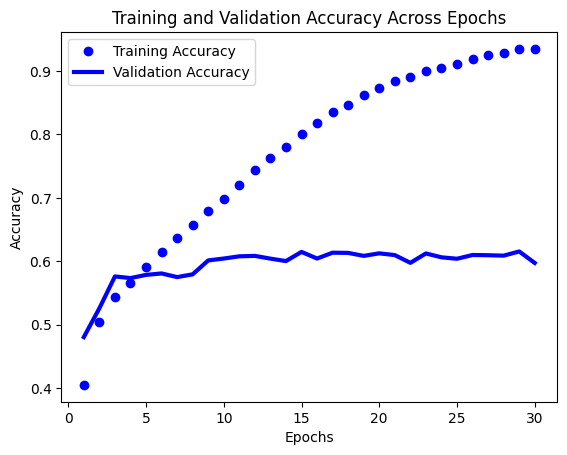

In [ ]:
plot_accuracy(partial_model_history)

225/225 [==============================] - 1s 3ms/step
*************************
* Test Accuracy: 0.6000 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,489,9,194,56,114,17,79
disgust,21,71,8,0,6,1,4
fear,103,6,605,34,146,50,80
happy,61,4,113,1415,71,18,92
sad,133,5,303,93,537,12,164
surprise,19,3,149,50,25,566,19
neutral,69,5,197,131,187,20,624


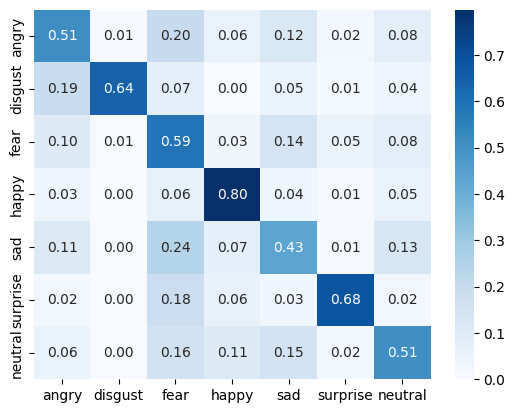

In [ ]:
show_confusion_matrix(partial_model)

Please comment briefly on the model's performance using the accuracy curve, test accuracy and confusion matrix.  

<font color='red'> **Your Answer** </font>

_This model performs fairly well with a test accuracy of 60.0%. The confusion matrix shows that most classes are correctly classified, except for a few._

## Part (c): Fine Tuning [5 Points]
Now, let's try a transfer learning model where all layers can be fine tuned.

In [ ]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add layers from base_model
for layer in base_model.layers:
    x = layer(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

tuned_model = keras.Model(inputs, outputs, name='full_fine_tune_model')

# Let's see which layers are trainable
for i, layer in enumerate(tuned_model.layers):
    print('Layer %d: %s (%s), Trainable=%s' % (i+1, layer.name, layer.__class__.__name__, layer.trainable))

Layer 1: input_10 (InputLayer), Trainable=True
Layer 2: random_flip_5 (RandomFlip), Trainable=True
Layer 3: random_zoom_5 (RandomZoom), Trainable=True
Layer 4: rescaling_8 (Rescaling), Trainable=True
Layer 5: input_9 (InputLayer), Trainable=True
Layer 6: block1_conv1 (Conv2D), Trainable=True
Layer 7: block1_conv2 (Conv2D), Trainable=True
Layer 8: block1_pool (MaxPooling2D), Trainable=True
Layer 9: block2_conv1 (Conv2D), Trainable=True
Layer 10: block2_conv2 (Conv2D), Trainable=True
Layer 11: block2_pool (MaxPooling2D), Trainable=True
Layer 12: block3_conv1 (Conv2D), Trainable=True
Layer 13: block3_conv2 (Conv2D), Trainable=True
Layer 14: block3_conv3 (Conv2D), Trainable=True
Layer 15: block3_conv4 (Conv2D), Trainable=True
Layer 16: block3_pool (MaxPooling2D), Trainable=True
Layer 17: block4_conv1 (Conv2D), Trainable=True
Layer 18: block4_conv2 (Conv2D), Trainable=True
Layer 19: block4_conv3 (Conv2D), Trainable=True
Layer 20: block4_conv4 (Conv2D), Trainable=True
Layer 21: block4_pool (

In [ ]:
tuned_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

tuned_model_history = tuned_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 [==============================] - 15s 12ms/step - loss: 1.4408 - accuracy: 0.4374 - val_loss: 1.2622 - val_accuracy: 0.5275
Epoch 2/30
718/718 [==============================] - 8s 11ms/step - loss: 1.2064 - accuracy: 0.5403 - val_loss: 1.1739 - val_accuracy: 0.5606
Epoch 3/30
718/718 [==============================] - 8s 11ms/step - loss: 1.1113 - accuracy: 0.5787 - val_loss: 1.0600 - val_accuracy: 0.5953
Epoch 4/30
718/718 [==============================] - 8s 11ms/step - loss: 1.0432 - accuracy: 0.6041 - val_loss: 1.0507 - val_accuracy: 0.6073
Epoch 5/30
718/718 [==============================] - 8s 11ms/step - loss: 0.9893 - accuracy: 0.6262 - val_loss: 1.0319 - val_accuracy: 0.6132
Epoch 6/30
718/718 [==============================] - 8s 11ms/step - loss: 0.9379 - accuracy: 0.6496 - val_loss: 1.0349 - val_accuracy: 0.6041
Epoch 7/30
718/718 [==============================] - 8s 11ms/step - loss: 0.8872 - accuracy: 0.6691 - val_loss: 1.0051 - val_accuracy: 0.629

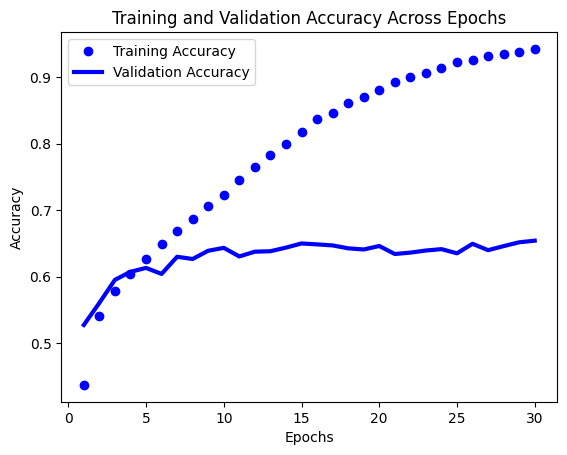

In [ ]:
plot_accuracy(tuned_model_history)

225/225 [==============================] - 1s 3ms/step
*************************
* Test Accuracy: 0.6491 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,545,9,108,46,101,26,123
disgust,32,62,6,1,4,2,4
fear,112,1,520,26,157,83,125
happy,41,2,32,1515,33,37,114
sad,128,6,207,75,517,26,288
surprise,18,2,89,33,14,661,14
neutral,60,1,103,80,116,34,839


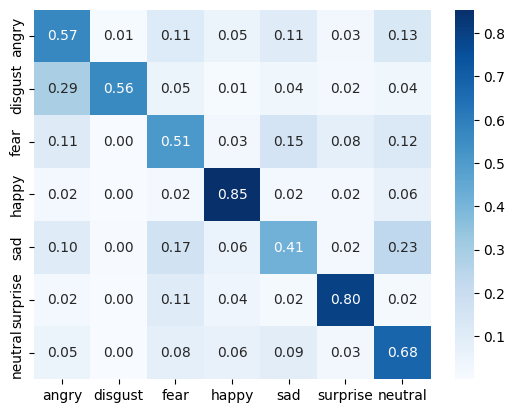

In [ ]:
show_confusion_matrix(tuned_model)

Please comment very briefly on the model's performance using the accuracy curve, test accuracy and confusion matrix.  

<font color='red'> **Your Answer** </font>

_This model performs fairly well with a test accuracy of 65%. There is little sign of overfitting. The confusion matrix shows that most classes are correctly classified, except for a few._

## Part (d): Comparison [10 Points]

Please fill in the table below with the test accuracies of the three models above, as well as that of `wider_model` from Problem 2.

<font color='red'>**Your Answer.**</font>

Model Test Accuracy:
* Model (a) with no fine tuning: 37%
* Model (b) with some fine tuning: 62%
* Model (c) with fine tuning: 64%
* `wider_model` from Problem 2(a)-(c): 50%


Comment on the performance of Models (a), (b) and (c). In particular, please address the following questions:

* Why do models (b) and (c) perform so much better than `wider_model`?
* Why do you think Model (a) performs so poorly?
* Why do you think Model (c) performs better than model (b)?

<font color='red'>**Your Answer.**</font>


* Models (b) and (c) highlight the value of transfer learning. They utilize pre-trained representations from VGG19, a model architecture trained on millions of images from ImageNet. `wider_model` was only trained on the ~20,000 images from the training data, making it less powerful. By using the pre-trained weights, Models (b) and (c) do not need to "reinvent the wheel" as some patterns and shapes used for detecting everyday objects can be translated to detecting emotions.

* The reason why model (a) performs so poorly is that the representations extracted by VGG19 may not be useful on their own in predicting facial expression. VGG19 is great at classifying images of animals, landscapes...etc, but such features may not be the ones best suited for classifying human facial expressions. By allowing models (b) and (c) to fine tune the convolution filters in VGG19, those models can learn represntations that are more useful for the specific task of facial emotion classification, as opposed to just a general image classification problem.

* Model (c) is a more versatile model with more parameters to tune because more parts of VGG19 can be trained. This additional flexibility led to better performance in this case, but this is not guaranteed. A model with more parameters to tune can overfit more easily.  